### Thierry (Assister par IA)
## Carte de clustering

In [15]:
!git clone https://github.com/Dackss/ProjetIA.git

fatal: destination path 'ProjetIA' already exists and is not an empty directory.


In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
import folium
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
# Chargement des données IRVE
irve = pd.read_csv("ProjetIA/data/export_IA.csv")

irve.head()

C:\Users\thier\AppData\Local\Temp\ipykernel_22420\3594809920.py:14: DtypeWarning: Columns (0: code_insee, 1: prise_ef, 2: prise_type2, 3: prise_ccs, 4: prise_chademo, 5: prise_autre, 6: deux_roues, 7: paiement_acte, 8: paiement_cb, 9: reservation) have mixed types. Specify dtype option on import or set low_memory=False.
  irve = pd.read_csv("ProjetIA/data/export_IA.csv")


,id_pdc,id_station,id_station_local,id_pdc_local,nom_station,nom_amenageur,siren_amenageur,contact_amenageur,operateur,contact_operateur,...,gratuit,paiement_acte,paiement_cb,paiement_autre,tarification_brute,condition_acces,reservation,horaires,date_service,date_maj
0,DKMONE3785539,DKMONE3785539,NaN,NaN,Golf de Garonne,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,Mo-Su 08:00-19:00,2024-10-24,2024-10-23
1,DKMONE3785590,DKMONE3785539,NaN,NaN,Golf de Garonne,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,Mo-Su 08:00-19:00,2024-10-24,2024-10-23
2,DKMONE3785709,DKMONE3785709,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,True,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30
3,DKMONE3785711,DKMONE3785711,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,True,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30
4,DKMONE3785713,DKMONE3785713,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30


## Apprentissage non-supervisé

In [17]:
# Extraction de la longitude et latitude
X = irve[["latitude", "longitude"]]


## Recherche de nombre de cluster

In [18]:
results = []
range_n_clusters = [2, 3, 4, 5, 6, 7,12]

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # Calcul des métriques demandées
    sil = silhouette_score(X, cluster_labels, sample_size=5000, random_state=42)
    ch = calinski_harabasz_score(X, cluster_labels)
    db = davies_bouldin_score(X, cluster_labels)

    results.append(
        {"K": k, "Silhouette": sil, "Calinski-Harabasz": ch, "Davies-Bouldin": db}
    )

## Affichage du tableau comparatif pour votre rapport


--- TABLEAU DES MÉTRIQUES D'ÉVALUATION ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2    0.429095      110941.820298        0.984881
 3    0.473423      137524.361620        0.742466
 4    0.483410      143551.465010        0.706245
 5    0.511239      174391.514330        0.694862
 6    0.500574      171598.553677        0.745013
 7    0.513699      176903.630090        0.730877
12    0.494585      191933.284649        0.704414
------------------------------------------


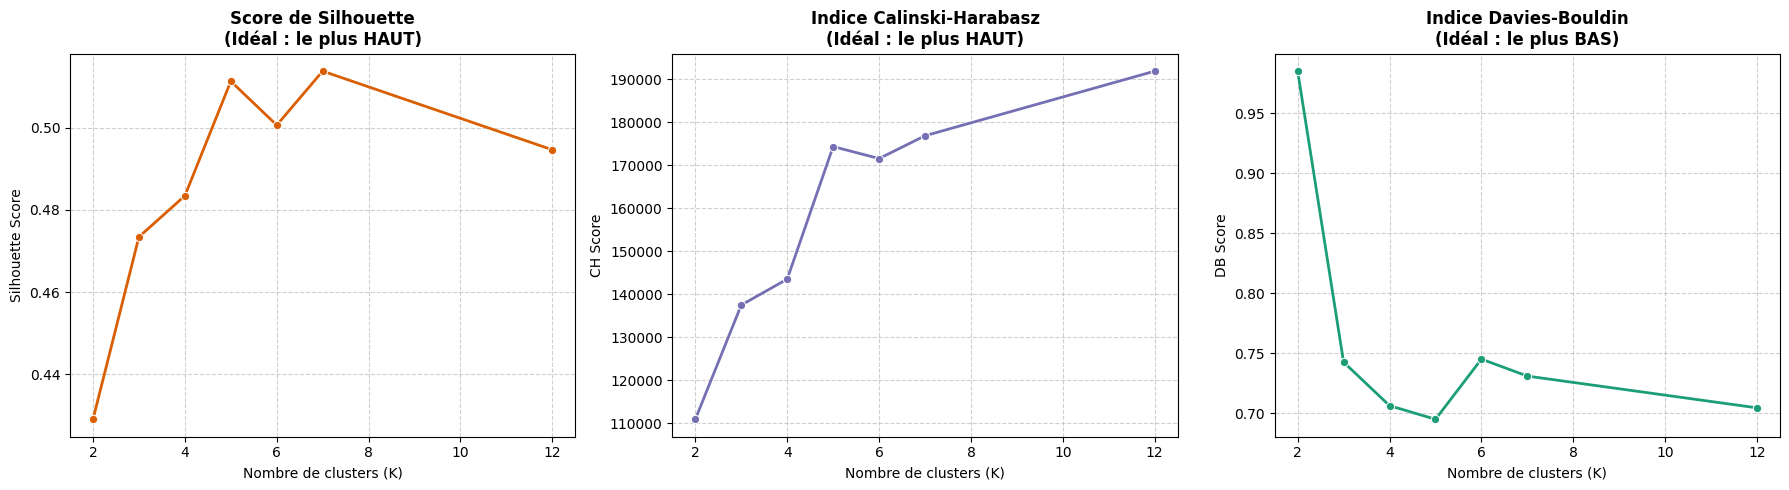


Entraînement du modèle final avec K=5...
Modèle sauvegardé avec succès sous le nom : 'kmeans_irve_model.pkl'


In [19]:
# Affichage du tableau comparatif pour votre rapport
df_metrics = pd.DataFrame(results)
print("\n--- TABLEAU DES MÉTRIQUES D'ÉVALUATION ---")
print(df_metrics.to_string(index=False))
print("------------------------------------------")
# 2. Configuration de l'affichage (1 ligne, 3 graphiques)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Score de Silhouette
sns.lineplot(ax=axes[0], data=df_metrics, x='K', y='Silhouette', marker='o', linewidth=2, color='#d95f02')
axes[0].set_title("Score de Silhouette\n(Idéal : le plus HAUT)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Graphique 2 : Indice Calinski-Harabasz
sns.lineplot(ax=axes[1], data=df_metrics, x='K', y='Calinski-Harabasz', marker='o', linewidth=2, color='#7570b3')
axes[1].set_title("Indice Calinski-Harabasz\n(Idéal : le plus HAUT)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("CH Score")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Graphique 3 : Indice Davies-Bouldin
sns.lineplot(ax=axes[2], data=df_metrics, x='K', y='Davies-Bouldin', marker='o', linewidth=2, color='#1b9e77')
axes[2].set_title("Indice Davies-Bouldin\n(Idéal : le plus BAS)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Nombre de clusters (K)")
axes[2].set_ylabel("DB Score")
axes[2].grid(True, linestyle='--', alpha=0.6)

# Ajustement automatique des espaces et affichage
plt.tight_layout()
plt.show()
best_k = 5
print(f"\nEntraînement du modèle final avec K={best_k}...")
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_kmeans.fit(X)

# SAUVEGARDE STRICTE DU MODÈLE

model_filename = "kmeans_irve_model.pkl"
joblib.dump(final_kmeans, model_filename)
print(f"Modèle sauvegardé avec succès sous le nom : '{model_filename}'")

## Creation de la carte de clustering

In [20]:
# Rechargement du modèle préalablement enregistré
final_kmeans = joblib.load("kmeans_irve_model.joblib")

# Assignation des clusters aux données existantes
X = irve[["latitude", "longitude"]]
irve["cluster"] = final_kmeans.predict(X)

# Création de la carte centrée sur la moyenne des positions
map_center = [irve["latitude"].mean(), irve["longitude"].mean()]
carte = folium.Map(location=map_center, zoom_start=6, tiles="CartoDB positron", prefer_canvas=True)

# Palette de couleurs pour différencier les clusters
colors = ["red", "blue", "green", "purple", "orange", "darkred", "cadetblue"]

# 4. Ajout des bornes sur la carte
for idx, row in irve.iterrows():
    cluster_id = int(row["cluster"])
    color = colors[cluster_id % len(colors)]

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=1,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"Borne ID: {idx}<br>Cluster: {cluster_id}",
    ).add_to(carte)

In [21]:
carte.save("carte_clusters_irve.html")
print(
    "La carte interactive a été générée sous le nom 'carte_clusters_irve.html'. Ouvrez-la dans un navigateur !"
)

La carte interactive a été générée sous le nom 'carte_clusters_irve.html'. Ouvrez-la dans un navigateur !
